# Intro

Why do language models need positional embeddings?

Consider the sentence:

"Hazelnuts are used as snack food, in baking and desserts, and in breakfast cereals such as muesli. In confectionery, they..."

Humans easily understand that "they" refers to "Hazelnuts". A language model, however, initially only sees a sequence of tokens.

Without positional information the model would only see a set of tokens and would not know their order. For example:

$$
\text{Hazelnuts cereals baking dessert they}
$$

Position embeddings provide information about the order of tokens in the sequence. They allow the transformer to distinguish between tokens appearing earlier and later in the text. This positional information is later used by the attention mechanism to determine relationships between tokens.

$$
x_i = e_i + p_i
$$

Here $e_i$ is the token embedding and $p_i$ is the positional embedding for token position $i$.

Where do positional embeddings come from?

There are two main approaches.

Fixed positional embeddings

- Sinusoidal embeddings  
- Based on mathematical sine and cosine functions  
- No additional parameters to train  

Learned positional embeddings

- Example: Learned Absolute Positional Embeddings (GPT-2)  
- Initialized randomly  
- Learned during training through gradient descent  

# Intuition

Let's examine how positional embeddings look and how they work. We will take Learned Absolute Positional Embeddings from GPT-2 just to illustrate what positional embeddings are. Just as a heads up, LAPE is not used very often; we usually use Sinusoidal or Rotary positional embeddings. However, those two rely on the exact same algebraic idea as LAPE - what differs is only how the positional embeddings are created. In LAPE, positional embeddings are derived from pretraining and are available in a matrix we can load from the gpt.wpe module. Sinusoidal and Rotary positional embeddings are created dynamically, without any fixed matrix as output that we can use.

Positional Embeddings in GPT-2 model are stored in Weight Positional Embeddings matrix (WPE), which have following shape:

In [ ]:
# @title
from transformers import GPT2Model

model = GPT2Model.from_pretrained("gpt2")
wpe = model.wpe.weight.detach().cpu().numpy()

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

GPT2Model LOAD REPORT from: gpt2
Key                  | Status     |  | 
---------------------+------------+--+-
h.{0...11}.attn.bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [ ]:
# @title
print('GPT-2 WPE shape:',wpe.shape)

GPT-2 WPE shape: (1024, 768)


Below we can see a positional embeddings matrix. To understand any 2D matrix we need to understand two things: what each row represents and what each column represents.

In [ ]:
print(wpe)

[[-1.8820720e-02 -1.9741860e-01  4.0267250e-03 ... -4.3043736e-02
   2.8267192e-02  5.4490108e-02]
 [ 2.3959434e-02 -5.3792033e-02 -9.4878644e-02 ...  3.4170013e-02
   1.0171850e-02 -1.5572949e-04]
 [ 4.2160717e-03 -8.4763914e-02  5.4514930e-02 ...  1.9744711e-02
   1.9324856e-02 -2.1423856e-02]
 ...
 [-1.7986511e-03  1.6052092e-03 -5.5103153e-02 ...  1.3616630e-02
  -7.1805264e-03  3.7552188e-03]
 [ 3.2105497e-03  1.5500595e-03 -4.8944373e-02 ...  2.0725457e-02
  -1.1837787e-02 -5.5682898e-04]
 [ 2.6609693e-04  3.0272407e-03 -1.7086461e-03 ... -4.6505518e-03
  -2.3541194e-03 -5.7855090e-03]]


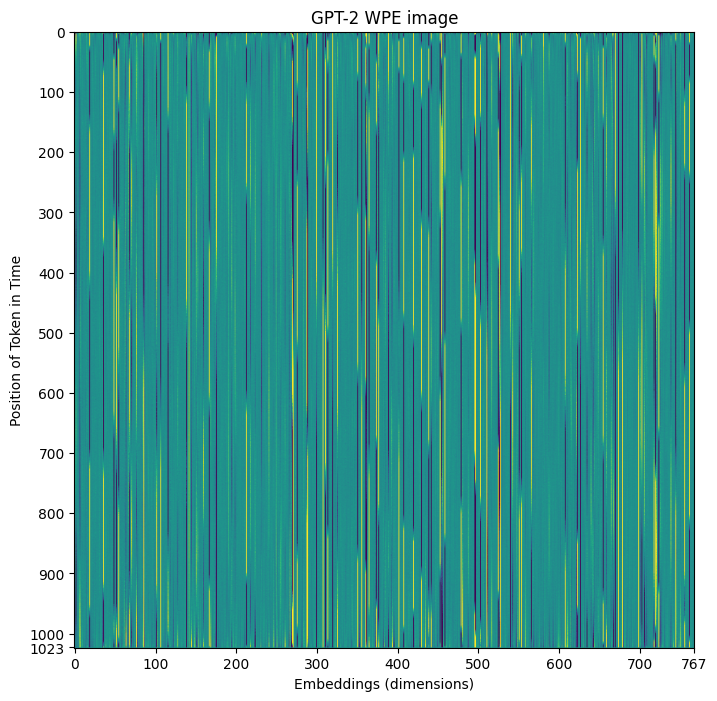

In [ ]:
# @title
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(8,8))
plt.imshow(wpe, aspect='auto', vmin=-.1, vmax=.1)

x_ticks = list(np.arange(0, wpe.shape[1], 100)) + [wpe.shape[1]-1]
y_ticks = list(np.arange(0, wpe.shape[0], 100)) + [wpe.shape[0]-1]

plt.xticks(x_ticks)
plt.yticks(y_ticks)

plt.xlabel('Embeddings (dimensions)')
plt.ylabel('Position of Token in Time')
plt.title('GPT-2 WPE image')

plt.show()

Just from this image we can grasp some initial intuition that there is structure in the vertical orientation. Vertical stripes appear to fade in and out. At the same time, we do not observe any clear structure in the horizontal orientation.

If we had a tokenizer where one token always corresponds to one word, and we input the text:

"I can see a red car driving through the highway."

each word would occupy a vertical position. "I" would correspond to position 0 on the y-axis, "can" would correspond to position 1, "see" to position 2, and so on. Horizontally, each of those words would have 768 parameters describing its position representation. We will explore this idea further in the following subsections.

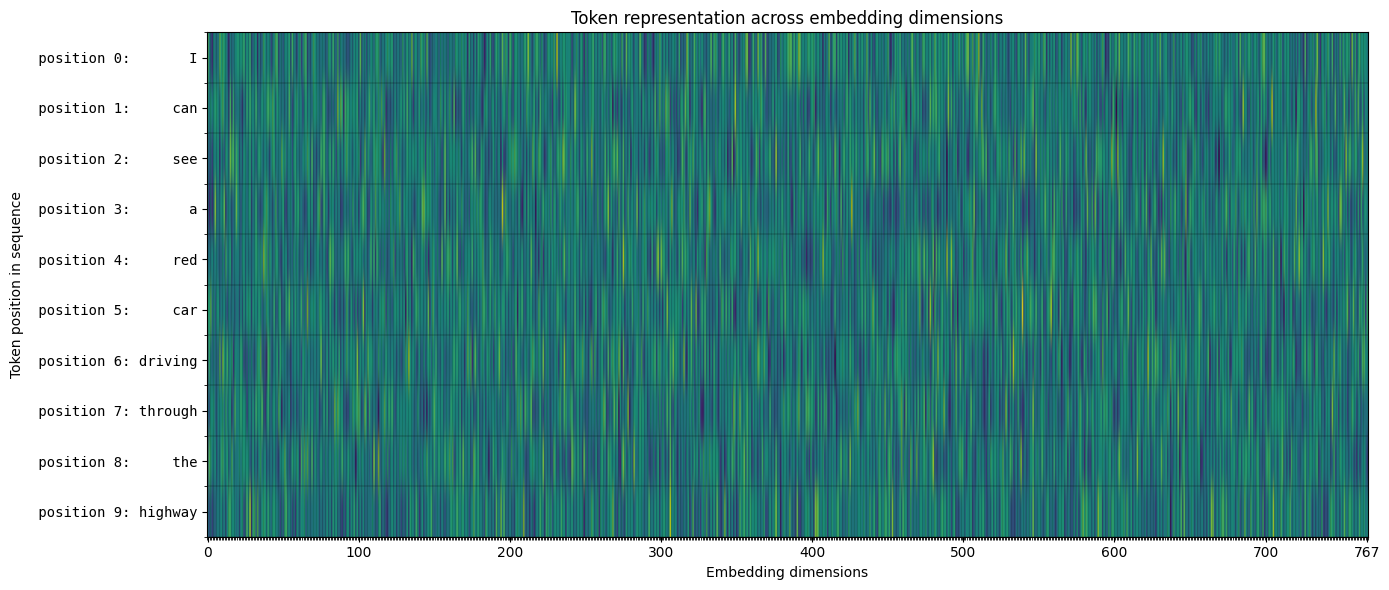

In [ ]:
# @title
import matplotlib.pyplot as plt
import numpy as np

raw_sentence = "I can see a red car driving through the highway"
sentence = raw_sentence.split()

seq_len = len(sentence)
dims = 768

grid = np.random.randn(seq_len, dims)

fig, ax = plt.subplots(figsize=(14,6))
im = ax.imshow(grid, aspect='auto')

y_labels = [f" position {i}: {token:>7}" for i, token in enumerate(sentence)]
ax.set_yticks(range(seq_len))
ax.set_yticklabels(y_labels, fontfamily="monospace")

x_ticks = list(np.arange(0, dims, 100)) + [dims-1]
ax.set_xticks(x_ticks)

ax.set_xlabel("Embedding dimensions")
ax.set_ylabel("Token position in sequence")
ax.set_title("Token representation across embedding dimensions")

ax.set_xticks(np.arange(-.5, dims, 1), minor=True)
ax.set_yticks(np.arange(-.5, seq_len, 1), minor=True)
ax.grid(which="minor", color="black", linewidth=0.2)

plt.tight_layout()
plt.show()


## Context Window

First, let us explain what a context window is. In GPT-2 the context window has **1024 tokens**. This means that when we give text to the model, it can process at most 1024 tokens at once. Each token has an order in the sequence: the 1st token, the 2nd token, the 3rd token and so on exactly as we've seen on above image. 1024 is maximum number of tokens we can input, if we will have text that have 1026 tokens model will return error, because WPE matrix doesn't have 1025th row (we count from 0).

In text, as in any sequence, order matters. If we change the order, we change the meaning of the sequence.

$$
[1,2,3] \neq [3,2,1]
$$

$$
\text{"Boy Ate Chocolate"} \neq \text{"Chocolate Ate Boy"}
$$

Because of this, the model must know where each token appears in the sequence. This is why positional embeddings are necessary.

## Row

Each row in the **WPE matrix** represents a **position of a token in the context window**.  
The first row corresponds to the first position in the sequence, the second row to the second position, and so on.

It is important to note that this does **not represent the token itself**, but only the **position where a token appears**.

Since GPT-2 has a context window of **1024 tokens**, the matrix contains **1024 rows**.

Each row is represented by a vector with **768 dimensions**. In other words, each position in the sequence is described by **768 numerical values**.

An intuitive analogy is describing a house. A house can be described by several attributes such as price, area, neighborhood or number of floors. Each attribute is a dimension. Similarly, here we describe the **position of a token** using 768 dimensions.

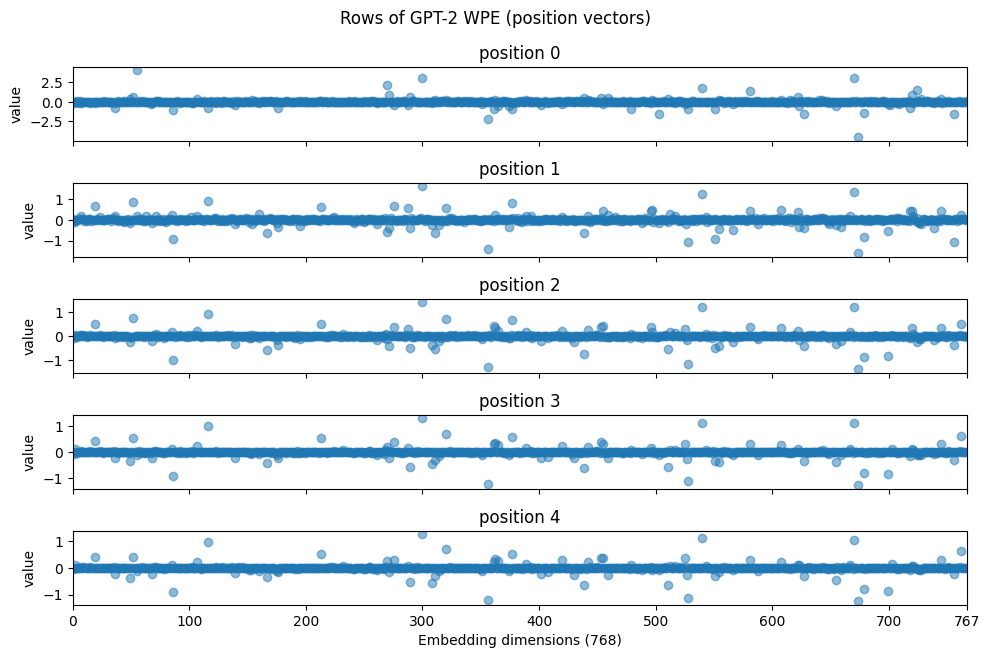

In [ ]:
n_positions, dims = wpe.shape


# ---- ROWS ----
rows = 5
fig, axes = plt.subplots(rows, 1, figsize=(10, 5*(n_positions/dims)), sharex=True)

# x ticks for dimensions
x_ticks = list(np.arange(0, dims, 100)) + [dims-1]

for i, ax in enumerate(axes):
    ax.plot(wpe[i],'o', alpha = .5)
    ax.set_xlim(0, dims-1)
    ax.set_xticks(x_ticks)
    ax.set_title(f"position {i}")
    ax.set_ylabel("value")

axes[-1].set_xlabel("Embedding dimensions (768)")

plt.suptitle("Rows of GPT-2 WPE (position vectors)")
plt.tight_layout()
plt.show()

As we can see, complete chaos.

## Column

Each column corresponds to **one dimension** of the positional embedding space. Since GPT-2 uses embeddings of size **768**, the WPE matrix contains **768 columns**.

Understanding rows is relatively straightforward because they represent positions in the sequence. Columns are slightly less intuitive.

Before going deeper, we introduce the idea of a **context signal**. This is simply an abstract signal that captures potential relationships between words in a sequence.

Consider the following text:

"I looked at the bottle, I picked it up, I drank water from it, I put it down."

Here the word *it* appears several times and refers to the same object, the bottle. For the model to understand this relationship it must know that the token referring to the bottle appeared earlier in the sequence.

Now consider another example:

"I was looking at the bottle when someone knocked on the door, so I had to open it."

In this sentence the word *it* refers to the *door*, not the bottle. The difference comes from the **positions of tokens in the sequence**.

This illustrates why positional information is required. Positional embeddings allow the model to reason about relationships between tokens based on their **relative positions**.

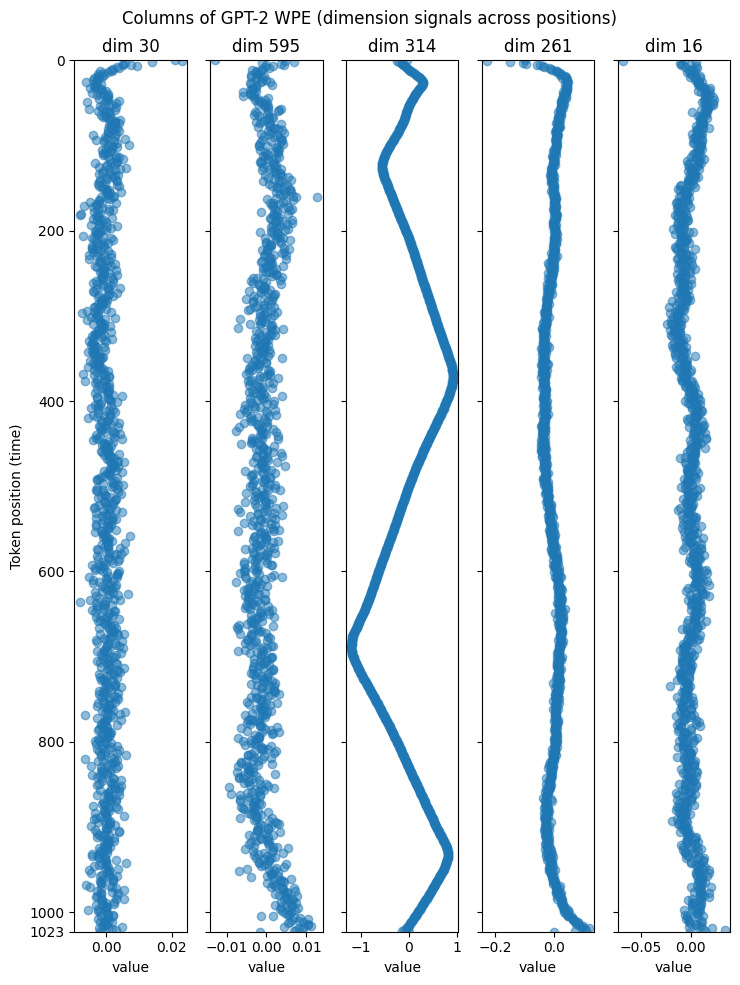

In [ ]:
# @title
# ---- COLUMNS ----
cols = 5
chosen_dims = np.random.choice(dims, cols, replace=False)

fig, axes = plt.subplots(1, cols, figsize=(10*(dims/n_positions), 10), sharey=True)

# y ticks for positions
y_ticks = list(np.arange(0, n_positions, 200)) + [n_positions-1]

for ax, d in zip(axes, chosen_dims):
    ax.plot(wpe[:, d], np.arange(n_positions), 'o', alpha = .5)
    ax.set_ylim(n_positions-1, 0)
    ax.set_yticks(y_ticks)
    ax.set_title(f"dim {d}")
    ax.set_xlabel("value")

axes[0].set_ylabel("Token position (time)")

plt.suptitle("Columns of GPT-2 WPE (dimension signals across positions)")
plt.tight_layout()
plt.show()

Well, it looks like dimentions have some underlying structure.

## Algebraic Intuition

If we look at the matrix column-wise, the **first column contains 1024 values**, one for each position in the context window. In this interpretation, a single dimension can be seen as a **signal evolving across positions in the sequence**.

Since the embedding size is **768**, we have **768 such signals** available simultaneously.

During processing, the transformer does not rely on a single signal. Instead, linear operations combine information from many dimensions. The model can take a portion of signal 1, a portion of signal 2, a portion of signal 231, and so on.

Through these combinations the network constructs a representation that integrates signals from many dimensions in order to match the structure of the input text.

If we had a sentence represented with only 5 embedding dimensions, each dimension could be interpreted as one potential context signal evolving across token positions.

The model combines these signals using a linear combination:

$$
c_i = w_1 s_{i1} + w_2 s_{i2} + w_3 s_{i3} + w_4 s_{i4} + w_5 s_{i5}
$$

Here $s_{ij}$ is the value of signal $j$ at token position $i$, and $w_j$ determines how strongly that signal contributes to the final combined context signal $c_i$.

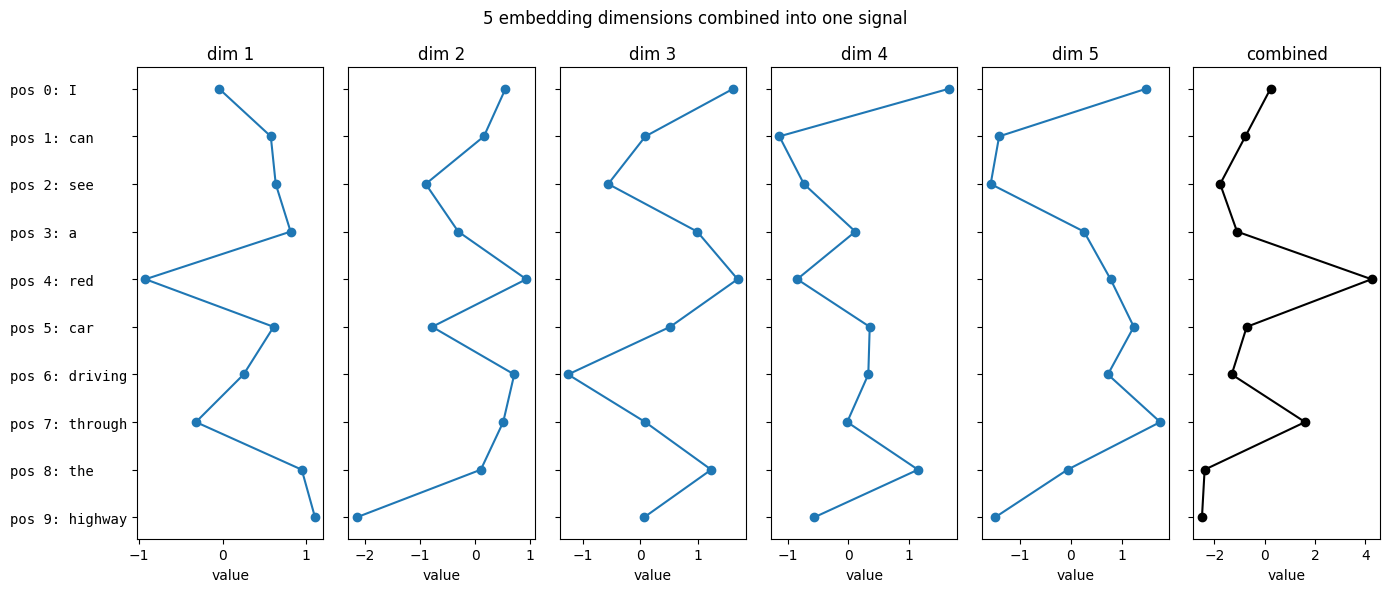

In [ ]:
# @title
import matplotlib.pyplot as plt
import numpy as np

raw_sentence = "I can see a red car driving through the highway"
tokens = raw_sentence.split()

seq_len = len(tokens)
dims = 5  # pretend we only have 5 dimensions

# simulate embedding slice
emb = np.random.randn(seq_len, dims)

signals = emb

weights = np.random.randn(dims)

# combined signal
final_signal = signals @ weights

fig, axes = plt.subplots(1, dims+1, figsize=(14,6), sharey=True)

y = np.arange(seq_len)

# plot the 5 dimensions
for i in range(dims):
    axes[i].plot(signals[:, i], y, 'o-')
    axes[i].set_title(f"dim {i+1}")
    axes[i].set_xlabel("value")
    axes[i].invert_yaxis()

# combined signal
axes[-1].plot(final_signal, y, 'o-', color='black')
axes[-1].set_title("combined")
axes[-1].set_xlabel("value")

axes[0].set_yticks(y)
axes[0].set_yticklabels([f"pos {i}: {t:<7}" for i, t in enumerate(tokens)], fontfamily="monospace")

plt.suptitle("5 embedding dimensions combined into one signal")
plt.tight_layout()
plt.show()

## Similarities across vectors

In [ ]:
positions = model.wpe.weight.detach().numpy()

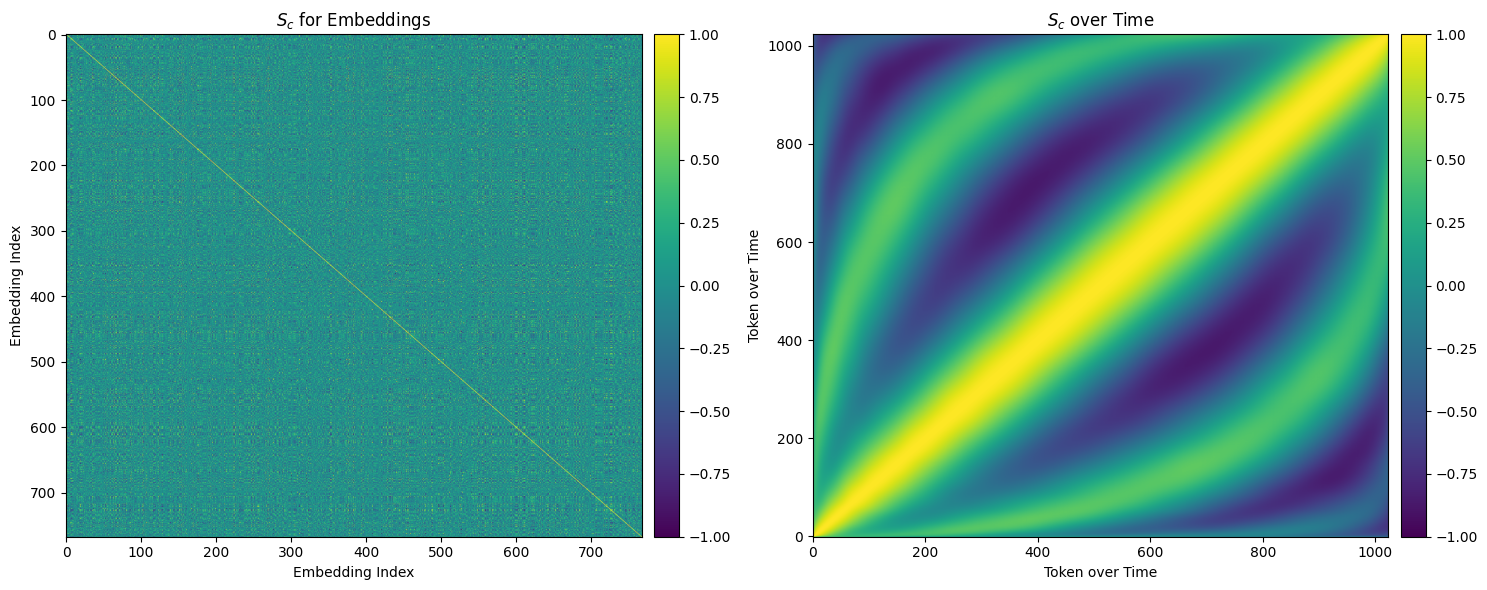

In [ ]:
# @title
# cosine similarity for "time series" tokens
p_norm_1 = positions / np.linalg.norm(positions, axis = 1, keepdims = True) # axis = 1 means we count norm for each row, so column-wise
cossim_1 = p_norm_1 @ p_norm_1.T # p_norm_1 returns (1024, 768) so we have need to transpose 2nd matrix to get (1024, 1024)

# cosine similarity for embeddings
p_norm_0 = positions / np.linalg.norm(positions, axis = 0, keepdims = True)
cossim_0 = p_norm_0.T @ p_norm_0 # p_norm_0 returns (1024, 768) so we need to transpose 1st matrix to get (768,768) after dot prod

fig, axs = plt.subplots(1,2,figsize = (15,6))

pl = axs[0].imshow(cossim_0, aspect = 'auto', vmin = -1, vmax = 1)
cb = plt.colorbar(pl, ax = axs[0], pad = 0.02, fraction = 0.046)
axs[0].set(title = '$S_c$ for Embeddings', xlabel = 'Embedding Index', ylabel = 'Embedding Index')

pl = axs[1].imshow(cossim_1, aspect = 'auto', vmin = -1, vmax = 1, origin = 'lower')
cb = plt.colorbar(pl, ax = axs[1], pad = 0.02, fraction = 0.046)
axs[1].set(title = '$S_c$ over Time', xlabel = 'Token over Time', ylabel = 'Token over Time')

plt.tight_layout()
plt.show()

That plot shows that cosine similarities between each column, i.e. each dimension (left plot) is completely random, there is no logic.

On the contrary right plot shows that cosine similarities between each row have relationship. That means in GPT2 positional embeddings assume positions of tokens have ALWAYS fixed relationship. It assumes that within context window tokens e.g. on positions 42 and 892 have ALWAYS same relationship.

This is of course oversimplified representation of text because different texts can have different orders. Just let's remember that this happens only in LAPE, in Sinusoidal Positional Embeddings and RoPE we don't use fixed, pretrained matrix of positional embeddings, which are completely dynamic, which is way better representation of how text actually works.

# Math

## Theoretical Minimum

### Vector Rotation

if

$$v = (x,y)$$

It's new coordinates after rotation are derived from trigonometry

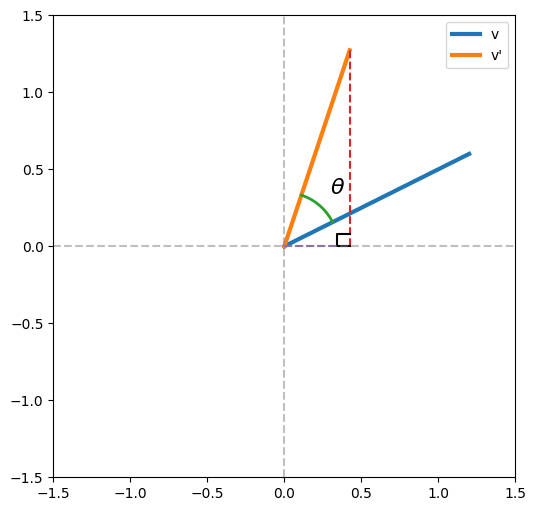

In [ ]:
# @title
import numpy as np
import matplotlib.pyplot as plt

v = np.array([1.2,0.6])
theta = np.pi/4

R = np.array([
    [np.cos(theta), -np.sin(theta)],
    [np.sin(theta),  np.cos(theta)]
])

v_rot = R @ v

fig, ax = plt.subplots(figsize=(6,6))

# vectors
ax.plot([0,v[0]],[0,v[1]],lw=3,label='v')
ax.plot([0,v_rot[0]],[0,v_rot[1]],lw=3,label="v'")

# angle between vectors
angle1 = np.arctan2(v[1],v[0])
angle2 = np.arctan2(v_rot[1],v_rot[0])

t = np.linspace(angle1,angle2,100)
r = .35
ax.plot(r*np.cos(t),r*np.sin(t),lw=2)
ax.text(.45*np.cos((angle1+angle2)/2),
        .45*np.sin((angle1+angle2)/2),
        r'$\theta$',fontsize=16)

# projection triangle
ax.plot([v_rot[0],v_rot[0]],[0,v_rot[1]],'--')
ax.plot([0,v_rot[0]],[0,0],'--')

# right angle marker
s=.08
ax.plot([v_rot[0],v_rot[0]-s,v_rot[0]-s,v_rot[0]],
        [0,0,s,s],color='black')

plt.axhline(0, linestyle = '--', color = 'grey', alpha = .5)
plt.axvline(0, linestyle='--', color = 'grey', alpha = .5)

ax.set_aspect('equal')
ax.set_xlim(-1.5,1.5)
ax.set_ylim(-1.5,1.5)

ax.legend()
plt.show()

$$
\sin\theta = \frac{\text{opposite}}{\text{hypotenuse}}
$$

$$
\cos\theta = \frac{\text{adjacent}}{\text{hypotenuse}}
$$

$$
\sin\theta = \frac{y'}{x}
$$

$$
y' = x\sin\theta
$$

$$
\cos\theta = \frac{x'}{x}
$$

$$
x' = x\cos\theta
$$

$$
\sin\theta = \frac{x''}{y}
$$

$$
x'' = y\sin\theta
$$

$$
\cos\theta = \frac{y''}{y}
$$

$$
y'' = y\cos\theta
$$

$$
x' = x\cos\theta - y\sin\theta
$$

$$
y' = x\sin\theta + y\cos\theta
$$

Now we wrap it in a vector and obtain the rotation matrix:

$$
\begin{bmatrix}
x' \\
y'
\end{bmatrix}
=
\begin{bmatrix}
\cos\theta & -\sin\theta \\
\sin\theta & \cos\theta
\end{bmatrix}
\begin{bmatrix}
x \\
y
\end{bmatrix}
$$

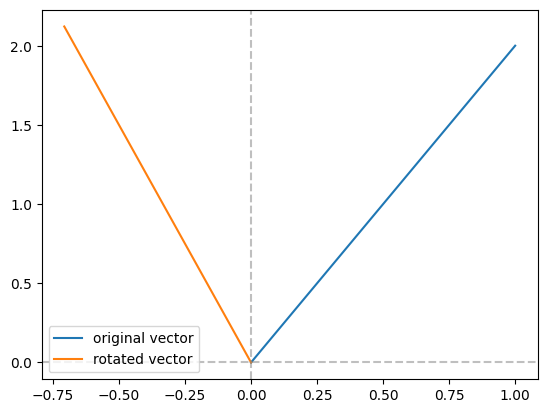

In [ ]:
# @title
v = np.array([1,2])

theta = np.pi/4
rot_mat = np.array([
                   [np.cos(theta), -np.sin(theta)],
                   [np.sin(theta), np.cos(theta)]
                   ])
rot_v = rot_mat @ v

plt.figure()
plt.plot([0, v[0]], [0, v[1]], label = 'original vector')
plt.plot([0, rot_v[0]], [0, rot_v[1]], label = 'rotated vector')
plt.axhline(0, linestyle = '--', color = 'grey', alpha = .5)
plt.axvline(0, linestyle='--', color = 'grey', alpha = .5)
plt.legend()
plt.show()

### Unit Circle

Circle with radius of 1 unit

$$ x^2 + y^2 = 1 $$
$$ y^2 = 1 - x^2 $$
$$ y = \pm\sqrt{1-x^2} $$

Let's paint!

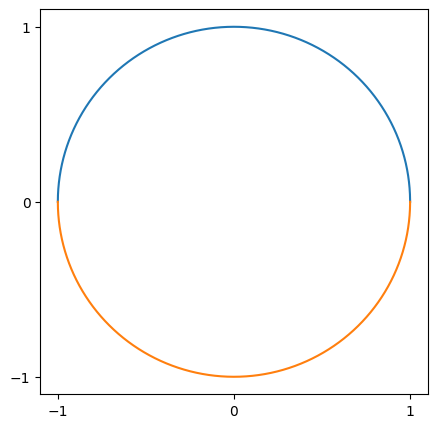

In [ ]:
# @title
import numpy as np
import matplotlib.pyplot as plt

x = np.linspace(-1, 1, 10**5)
y = np.sqrt(1-x**2)

plt.figure(figsize = (5,5))
plt.plot(x, y)
plt.plot(x, -y)
plt.xticks([-1,0,1])
plt.yticks([-1,0,1])
plt.show()

### Point on Circle

From vector rotation section we know that:

$$ x = \cos\theta $$
$$ y = \sin\theta $$

$$
v_\theta = (\cos\theta,\sin\theta)
$$

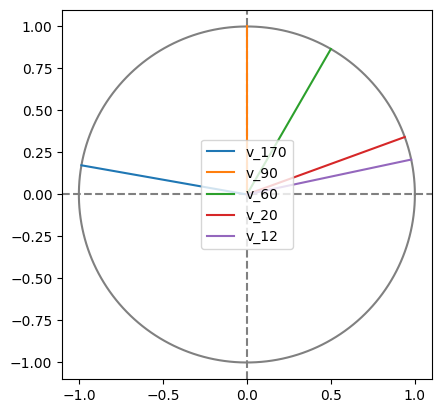

In [ ]:
# @title
import numpy as np
import matplotlib.pyplot as plt

# unit circle
t = np.linspace(0,2*np.pi,200)
plt.plot(np.cos(t), np.sin(t), color = 'gray')

# 170 deg
theta_170 = 170 * np.pi / 180
x_circle = np.cos(theta_170)
y_circle = np.sin(theta_170)
# vector on unit circle
plt.plot([0,x_circle], [0, y_circle], label = 'v_170')

# 90 deg
theta_90 = np.pi/2
x_circle = np.cos(theta_90)
y_circle = np.sin(theta_90)
# vector on unit circle
plt.plot([0,x_circle], [0, y_circle], label = 'v_90')

# 60 deg
theta_60 = np.pi/3
x_circle = np.cos(theta_60)
y_circle = np.sin(theta_60)
# vector on unit circle
plt.plot([0,x_circle], [0, y_circle], label = 'v_60')

# 20 deg
theta_20 = np.pi/9
x_circle = np.cos(theta_20)
y_circle = np.sin(theta_20)
# vector on unit circle
plt.plot([0,x_circle], [0, y_circle], label = 'v_20')

# 12 deg
theta_12 = np.pi/15
x_circle = np.cos(theta_12)
y_circle = np.sin(theta_12)
# vector on unit circle
plt.plot([0,x_circle], [0, y_circle], label = 'v_12')

plt.axhline(0, linestyle = '--', color = 'grey', zorder = -3)
plt.axvline(0, linestyle = '--', color = 'grey', zorder = -3)

plt.gca().set_aspect('equal')
plt.legend()
plt.show()

That's how we plot vector on a circle.

### Dot Product of sin/cos

Let $v_a$ and $v_b$ are unit circle vector

$$
v_a = (\cos a,\sin a)
$$

$$
v_b = (\cos b,\sin b)
$$

Now, lets see how dot product of 2 vectors looks like taking into account formula from Point on Circle section.


$$
v_a \cdot v_b
$$

$$
= (\cos a,\sin a)\cdot(\cos b,\sin b)
$$

$$
= \cos a \cos b + \sin a \sin b
$$

From the geometric definition of the dot product:

$$
v_a \cdot v_b = |v_a||v_b|\cos(\theta)
$$

Since both vectors lie on the unit circle:

$$
|v_a| = |v_b| = 1
$$

therefore

$$
v_a \cdot v_b = \cos(\theta)
$$

The angle between the vectors is:

$$
\theta = a-b
$$

therefore

$$
\cos a \cos b + \sin a \sin b = \cos(a-b)
$$

By taking the dot product of two unit circle vectors, we obtain the cosine of the angle between them.

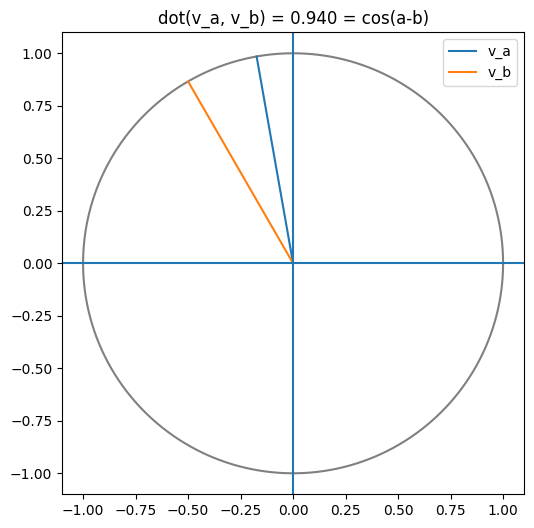

In [ ]:
# @title
import numpy as np
import matplotlib.pyplot as plt

# two angles
a = np.deg2rad(100)
b = np.deg2rad(120)

# unit circle vectors
v_a = np.array([np.cos(a), np.sin(a)])
v_b = np.array([np.cos(b), np.sin(b)])

# dot product
dot = np.dot(v_a, v_b)

# unit circle
t = np.linspace(0, 2*np.pi, 200)

plt.figure(figsize=(6,6))
plt.plot(np.cos(t), np.sin(t), color='gray')

# vectors
plt.plot([0, v_a[0]], [0, v_a[1]], label='v_a')
plt.plot([0, v_b[0]], [0, v_b[1]], label='v_b')

plt.axhline(0)
plt.axvline(0)

plt.gca().set_aspect('equal')
plt.title(f"dot(v_a, v_b) = {dot:.3f} = cos(a-b)")
plt.legend()

plt.show()

## Positional Embeddings Core Formula

At its core Position Embeddings make it possible for the model to understand the sequence from an order perspective, or context. Without Position Embeddings the sentences

$$ \text{"Boy ate chocolate"} $$
$$ \text{"Chocolate ate boy"} $$

would mean exactly the same thing for the model. However, how does this work from a mathematical perspective?

To understand that we need to look at the Attention formula which looks as follows:

$$ h_i = e_i + p_i $$

where:

* $e_i$ - word embedding responsible for semantics, in the GPT2 model it is located in the WeightTokenEmbeddings matrix
* $p_i$ - positional embedding, responsible for the position or placement of the word in time.

We can add both embeddings because both have exactly the same dimensionality, which is crucial. In the GPT2 model each embedding has 768 dimensions regardless of whether it is a positional or token embedding.

Now, when we have two words $h_i$ and $h_j$, each word is represented by two embeddings: a token embedding and a positional embedding. To see the relationship between two words, we multiply their representations.

$$ \text{Attention Score}(Q,K,V) = \text{softmax}(\alpha_{ij})\,V $$

Where

$$\alpha_{ij}= \frac{q_i \cdot k_j}{\sqrt{d}} $$

Where, $q_i = W_Q h_i$, $k_j = W_K h_j$ and $d = 768$ in GPT2. Eventually we get the following formula

$$\frac{
(W_Q e_i)\cdot(W_K e_j)
+
(W_Q e_i)\cdot(W_K p_j)
+
(W_Q p_i)\cdot(W_K e_j)
+
(W_Q p_i)\cdot(W_K p_j)
}{\sqrt{d}}$$

To understand what Positional Embeddings do, let's drop the weights and scaling factor for now, giving:

$$
h_i \cdot h_j = (e_i + p_i) \cdot (e_j + p_j)
$$

$$
= e_i\cdot e_j + e_i\cdot p_j + p_i\cdot e_j + p_i\cdot p_j
$$

As we can see, each relationship between words is "bounded" in four ways:

* $e_ie_j$ - meaning of $\text{word}_i$ and meaning of $\text{word}_j$
* $e_ip_j$ - meaning of $\text{word}_i$ and position of $\text{word}_j$
* $p_ie_j$ - position of $\text{word}_i$ and meaning of $\text{word}_j$
* $p_ip_j$ - position of $\text{word}_i$ and position of $\text{word}_j$

Each multiplication is a dot product, i.e. we multiply vector norms and the cosine of the angle between them.

Now, the most interesting part is what happens in $p_i\cdot p_j$. The other three dot products are straightforward and behave like standard dot products. However, $p_i\cdot p_j$ includes "encoded" behaviour. In general, this term determines how the positional embedding of one word relates to the positional embedding of another word. This is part for which we mainly went through **Theoretical Minimum.**


There are three main ways of shaping the position-to-position relationship. We will go through each of them in the next section.

## Different ways of Postional Embeddings

### Learned Absolute Positional Embeddings

#### Theory

In LAPE we don't do any transformations.

$$ p_i = P[i] $$

Meaning we just take positional embedding $i$ from positional embedding matrix from row $i$. Therefore:

$$p_i \cdot p_j = |p_i||p_j| \cos(\theta)$$

Where $\theta$ is an angle between the vectors $p_i$ and $p_j$

In [ ]:
from transformers import GPT2Model, GPT2Tokenizer

gpt2 = GPT2Model.from_pretrained('gpt2')
gpt2_tokenizer = GPT2Tokenizer.from_pretrained('gpt2')

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

GPT2Model LOAD REPORT from: gpt2
Key                  | Status     |  | 
---------------------+------------+--+-
h.{0...11}.attn.bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Let's save positional embeddings

In [ ]:
pos_em = gpt2.wpe.weight.detach().numpy()
pos_em.shape

(1024, 768)

Now, we can take some sentences like:

In [ ]:
sentences = [
    "Men drives a car",
    "Men buys a car",
    "Men throws out car",
    "Men thinks about car"
]

for s in sentences:
    ids = gpt2_tokenizer.encode(s)
    toks = gpt2_tokenizer.convert_ids_to_tokens(ids)

    print(f"\nSentence: {s}")
    print("-"*40)
    for i, (tok, tid) in enumerate(zip(toks, ids)):
        print(f"{i:2d} | {tok:12s} | {tid}")


Sentence: Men drives a car
----------------------------------------
 0 | Men          | 10418
 1 | Ġdrives      | 10182
 2 | Ġa           | 257
 3 | Ġcar         | 1097

Sentence: Men buys a car
----------------------------------------
 0 | Men          | 10418
 1 | Ġbuys        | 24779
 2 | Ġa           | 257
 3 | Ġcar         | 1097

Sentence: Men throws out car
----------------------------------------
 0 | Men          | 10418
 1 | Ġthrows      | 12542
 2 | Ġout         | 503
 3 | Ġcar         | 1097

Sentence: Men thinks about car
----------------------------------------
 0 | Men          | 10418
 1 | Ġthinks      | 6834
 2 | Ġabout       | 546
 3 | Ġcar         | 1097


As we can see word "Men" and "car" are always at same shape in those 4 sentences and are placed at exactly same positions.

Now, let's compute the dot product for words "Men" and "car" in all those sentences:

$$
h_i \cdot h_j
$$

Since

$$
h_i = e_i + p_i
$$

and

$$
h_j = e_j + p_j
$$

we obtain

$$
h_i \cdot h_j = (e_i + p_i)\cdot(e_j + p_j)
$$

$$
= e_i\cdot e_j + e_i\cdot p_j + p_i\cdot e_j + p_i\cdot p_j
$$

In [ ]:
import torch

wte = gpt2.wte.weight
wpe = gpt2.wpe.weight

pairs = []

for s in sentences:

    print(f"\nSentence: {s}")

    ids  = gpt2_tokenizer.encode(s)
    toks = gpt2_tokenizer.convert_ids_to_tokens(ids)

    men_idx = toks.index("Men")
    car_idx = toks.index("Ġcar")

    print(f"Men idx: {men_idx}")
    print(f"Car idx: {car_idx}")

    e_i = wte[ids[men_idx]]
    p_i = wpe[men_idx]

    e_j = wte[ids[car_idx]]
    p_j = wpe[car_idx]

    eiej = torch.dot(e_i, e_j)
    eipj = torch.dot(e_i, p_j)
    piej = torch.dot(p_i, e_j)
    pipj = torch.dot(p_i, p_j)

    total = eiej + eipj + piej + pipj

    print(f"e_i·e_j = {eiej}")
    print(f"e_i·p_j = {eipj}")
    print(f"p_i·e_j = {piej}")
    print(f"p_i·p_j = {pipj}")
    print(f"h_i·h_j = {total}")

    pairs.append(total)


Sentence: Men drives a car
Men idx: 0
Car idx: 3
e_i·e_j = 2.8266077041625977
e_i·p_j = -0.4288587272167206
p_i·e_j = -1.2682685852050781
p_i·p_j = 21.570852279663086
h_i·h_j = 22.700332641601562

Sentence: Men buys a car
Men idx: 0
Car idx: 3
e_i·e_j = 2.8266077041625977
e_i·p_j = -0.4288587272167206
p_i·e_j = -1.2682685852050781
p_i·p_j = 21.570852279663086
h_i·h_j = 22.700332641601562

Sentence: Men throws out car
Men idx: 0
Car idx: 3
e_i·e_j = 2.8266077041625977
e_i·p_j = -0.4288587272167206
p_i·e_j = -1.2682685852050781
p_i·p_j = 21.570852279663086
h_i·h_j = 22.700332641601562

Sentence: Men thinks about car
Men idx: 0
Car idx: 3
e_i·e_j = 2.8266077041625977
e_i·p_j = -0.4288587272167206
p_i·e_j = -1.2682685852050781
p_i·p_j = 21.570852279663086
h_i·h_j = 22.700332641601562


In [ ]:
pairs

[tensor(22.7003, grad_fn=<AddBackward0>),
 tensor(22.7003, grad_fn=<AddBackward0>),
 tensor(22.7003, grad_fn=<AddBackward0>),
 tensor(22.7003, grad_fn=<AddBackward0>)]

As we can see, every time we obtain the same dot product between the two embeddings. This happens because in LAPE we use a learned positional embedding matrix with fixed positional vectors after training. If the words $h_i$ and $h_j$ are the same and appear at the same positions in two different sentences, the resulting dot product will be identical.

In other positional embedding methods, such as RoPE and sinusoidal embeddings, positional relationships are computed from mathematical functions rather than taken from a learned table. In those methods positional information is generated on the fly, while in LAPE positional embeddings come from a learned embedding matrix.

In other words if some model doesn't use LAPE, it means there is no such a thing like `model.wpe`.

##### How LAPE Matrix is built?

Let's see how we actually create token and positional embeddings.

Training a language model starts from a raw text corpus.

First the corpus is tokenized.

$$
\text{"Men drives a car"}
$$

$$
\rightarrow [1379, 12523, 257, 1097]
$$

Token embeddings are represented by a matrix:

$$
E \in \mathbb{R}^{V \times d}
$$

where $V$ is the vocabulary size and $d$ is the embedding dimension.

Positional embeddings in LAPE are represented by:

$$
P \in \mathbb{R}^{L \times d}
$$

where $L$ is the maximum sequence length.

Both matrices are randomly initialized:

$$
E_{ij}, P_{ij} \sim N(0,0.02)
$$

For a sequence of token IDs $t_1, t_2, \dots, t_n$ we obtain embeddings:

$$
e_i = E[t_i]
$$

$$
p_i = P[i]
$$

The transformer input is:

$$
h_i = e_i + p_i
$$

The model is trained to predict the next token:

$$
P(t_{i+1} \mid t_1, t_2, \dots, t_i)
$$

Gradients from the loss update both matrices:

$$
E \leftarrow E - \eta \nabla_E L
$$

$$
P \leftarrow P - \eta \nabla_P L
$$

To sum up token embeddings and positional embeddings (when using LAPE) are learned parameters of the model and are optimized during the transformer training process.

#### Positional Embeddings Breakdown

##### Absolute Positional Embeddings (Learned)

##### Generate

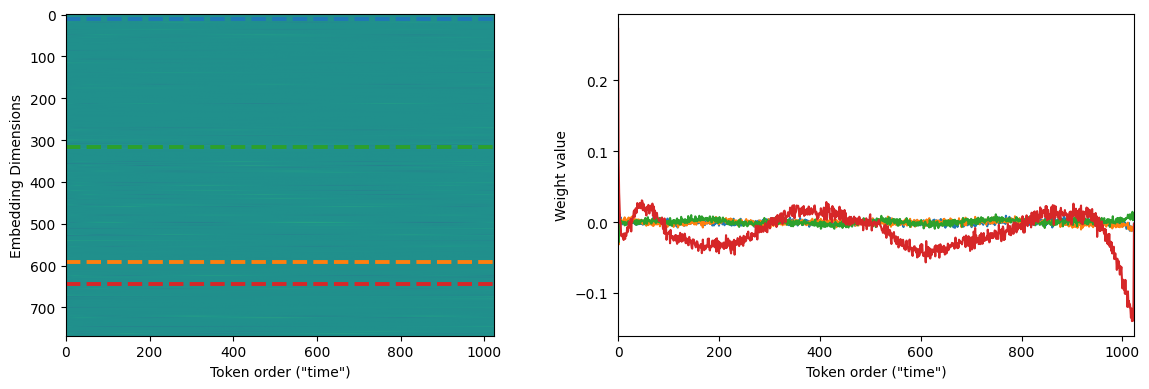

In [ ]:
# Absolute positional embeddings (learned) like in GPT-2

positions_absolute = gpt2.wpe.weight.data.cpu().numpy()

# viz heatmap
_, axs = plt.subplots(1,2,figsize=(12,4))

axs[0].imshow(positions_absolute.T, vmin=-np.abs(positions_absolute).max(), vmax=np.abs(positions_absolute).max())
axs[0].set(ylabel='Embedding Dimensions', xlabel='Token order ("time")')

# pick random embedding dimensions
poc2show = np.random.randint(0, positions_absolute.shape[1], 4)
h = axs[1].plot(positions_absolute[:, poc2show])
axs[1].set(ylabel='Weight value', xlabel='Token order ("time")', xlim=[0, positions_absolute.shape[0]], title="")

for i, p in enumerate(poc2show):
    axs[0].axhline(p, linestyle='--', color=h[i].get_color(), linewidth=2.8)

plt.tight_layout()
plt.show()

##### Visualize random embedding dimensions across positions

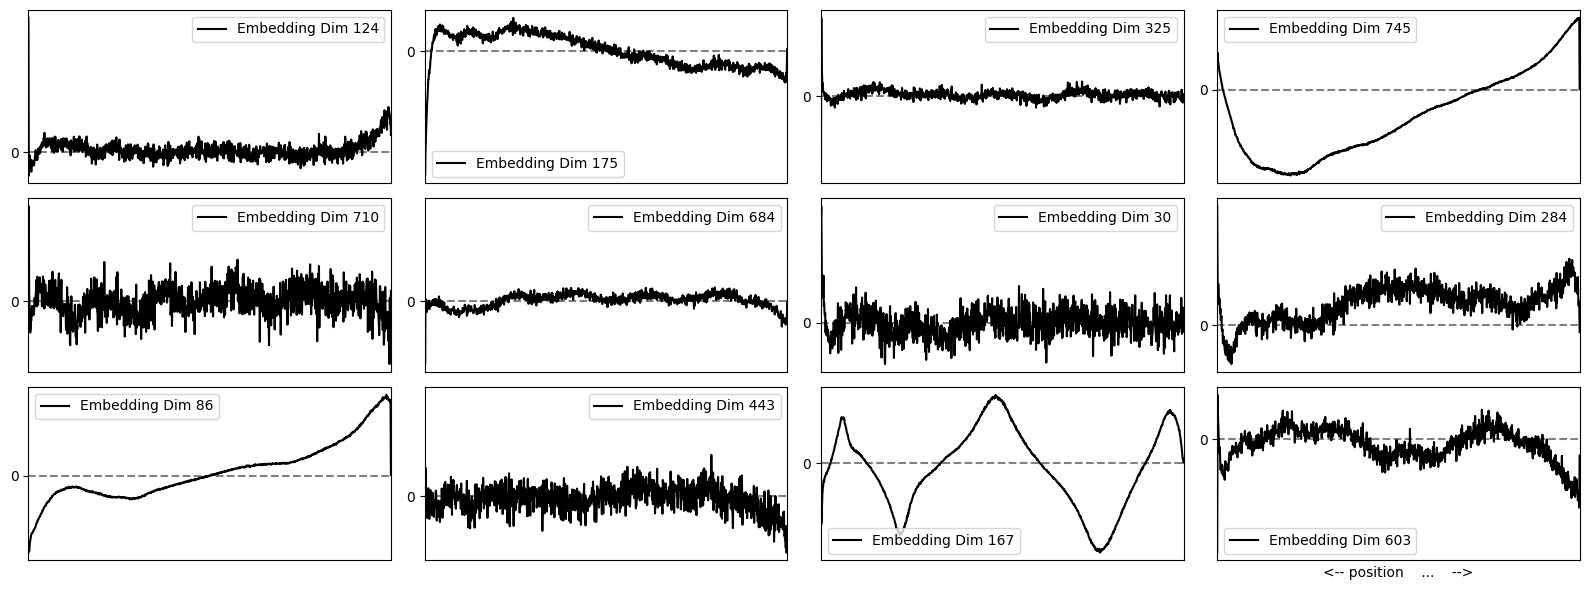

In [ ]:
# visualize random embedding dimensions across positions
_, axs = plt.subplots(3,4,figsize=(16,6))

for a in axs.flatten():
    rand_idx = np.random.randint(positions_absolute.shape[1])
    a.plot(positions_absolute[:, rand_idx], 'k', label=f'Embedding Dim {rand_idx}')
    a.axhline(0, linestyle='--', color='gray', zorder=-3)

    a.set(xticks=[], yticks=[0], xlim=[0, positions_absolute.shape[0]])
    a.legend(fontsize=10)

a.set(xlabel='<-- position    ...    -->')
plt.tight_layout()
plt.show()

##### Visualize random position vectors

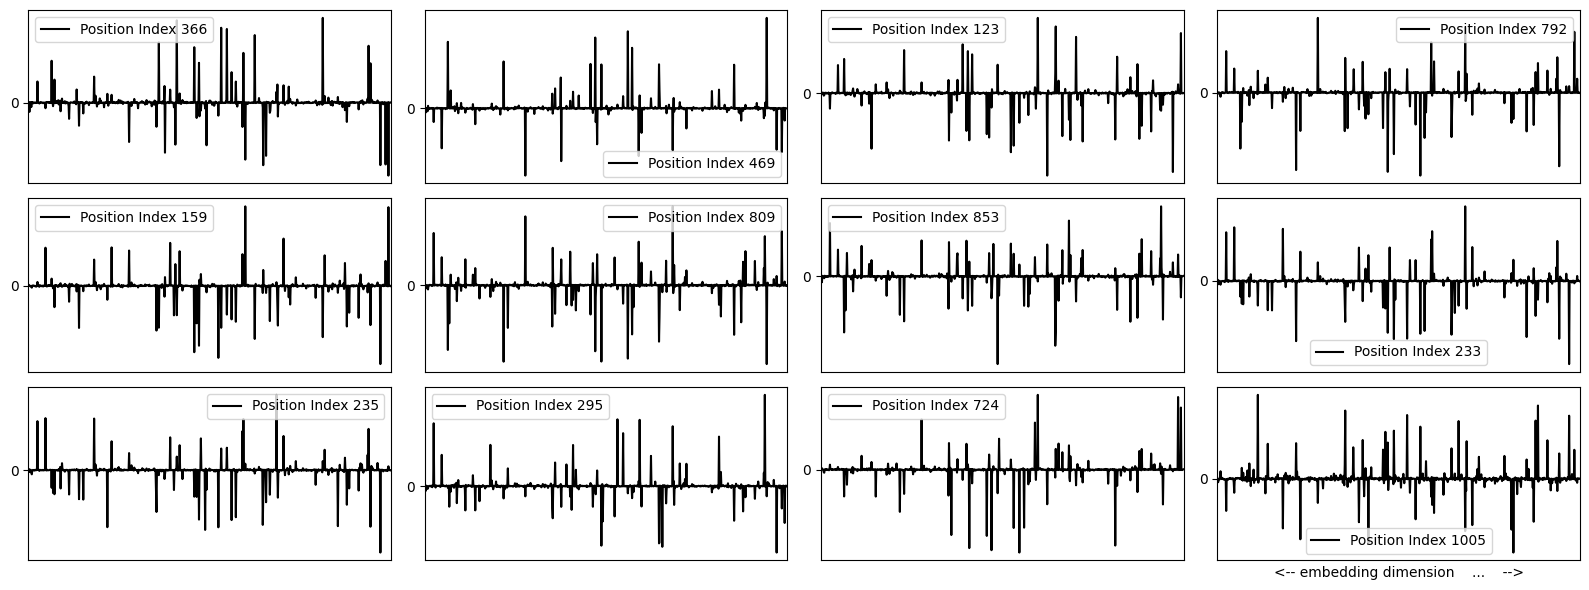

In [ ]:
# visualize random position vectors
_, axs = plt.subplots(3,4,figsize=(16,6))

for a in axs.flatten():
    rand_idx = np.random.randint(positions_absolute.shape[0])
    a.plot(positions_absolute[rand_idx, :], 'k', label=f'Position Index {rand_idx}')
    a.axhline(0, linestyle='--', color='gray', zorder=-3)

    a.set(xticks=[], yticks=[0], xlim=[0, positions_absolute.shape[1]])
    a.legend(fontsize=10)

a.set(xlabel='<-- embedding dimension    ...    -->')
plt.tight_layout()
plt.show()

### Sinusoidal embeddings as defined in "Attention" paper

#### Theory


Each token position is encoded using sine and cosine waves with different frequencies.

$$PE(pos,2i)=\sin\left(\frac{pos}{10000^{2i/d}}\right)$$

$$PE(pos,2i+1)=\cos\left(\frac{pos}{10000^{2i/d}}\right)$$

Each pair of dimensions forms a vector on the unit circle:

$$(\cos\theta,\sin\theta)$$

Token position $pos$ corresponds to rotating this vector by an angle proportional to $pos$.

Key property:

$$(\cos a,\sin a)\cdot(\cos b,\sin b)=\cos(a-b)$$

Therefore the dot product between two positional vectors encodes relative distance:

$$p_i \cdot p_j \propto \cos(i-j)$$

So attention can infer how far two tokens are from each other.

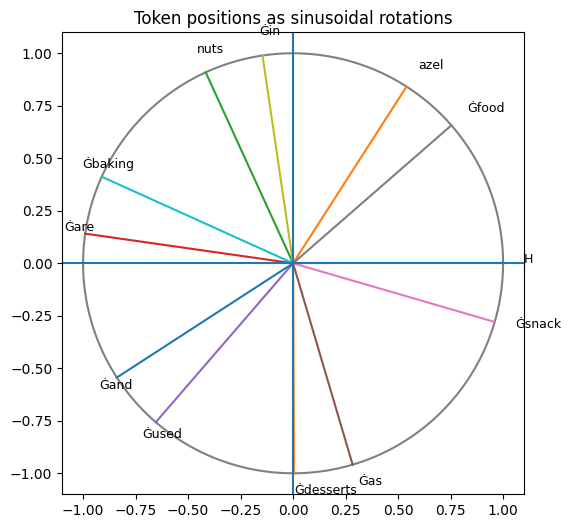




Sentence: Hazelnuts are used as snack food in baking and desserts
Tokens:   [('H', np.int64(0)), ('azel', np.int64(1)), ('nuts', np.int64(2)), ('Ġare', np.int64(3)), ('Ġused', np.int64(4)), ('Ġas', np.int64(5)), ('Ġsnack', np.int64(6)), ('Ġfood', np.int64(7)), ('Ġin', np.int64(8)), ('Ġbaking', np.int64(9)), ('Ġand', np.int64(10)), ('Ġdesserts', np.int64(11))]


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from transformers import GPT2Tokenizer

# sentence
sentence = "Hazelnuts are used as snack food in baking and desserts"

# tokenizer
tokenizer = GPT2Tokenizer.from_pretrained("gpt2")
ids = tokenizer.encode(sentence)
tokens = tokenizer.convert_ids_to_tokens(ids)

# positions
positions = np.arange(len(tokens))

# simple sinusoidal positional encoding (first 2 dims)
sin = np.sin(positions)
cos = np.cos(positions)

plt.figure(figsize=(6,6))

# unit circle
t = np.linspace(0,2*np.pi,200)
plt.plot(np.cos(t),np.sin(t),color="gray")

# plot token positions as rotated vectors
for i,(s,c) in enumerate(zip(sin,cos)):
    plt.plot([0,c],[0,s])
    plt.text(c*1.1,s*1.1,tokens[i],fontsize=9)

plt.axhline(0)
plt.axvline(0)
plt.gca().set_aspect("equal")
plt.title("Token positions as sinusoidal rotations")
plt.show()

print(f'\n\n\nSentence: {sentence}')
print("Tokens:  ",list(zip(tokens,positions)))

##### Why We are Using Sin/Cos

1. Constant magnitude  
$ \|(\cos\theta,\sin\theta)\| = 1 $  

This keeps positional vectors at a stable scale.

2. Relative position emerges from dot product  

$ (\cos a,\sin a)\cdot(\cos b,\sin b) = \cos(a-b) $

So the attention mechanism can infer distance between tokens.

3. Smooth positional change  

$ pos \rightarrow pos+1 $

produces a small rotation instead of a discrete jump.

4. Multiple frequencies encode long sequences  

$ \sin\left(\frac{pos}{10000^{2i/d}}\right), \cos\left(\frac{pos}{10000^{2i/d}}\right) $

Different frequencies allow the model to uniquely represent large positions.

#### Positional Embeddings Breakdown

##### Generate

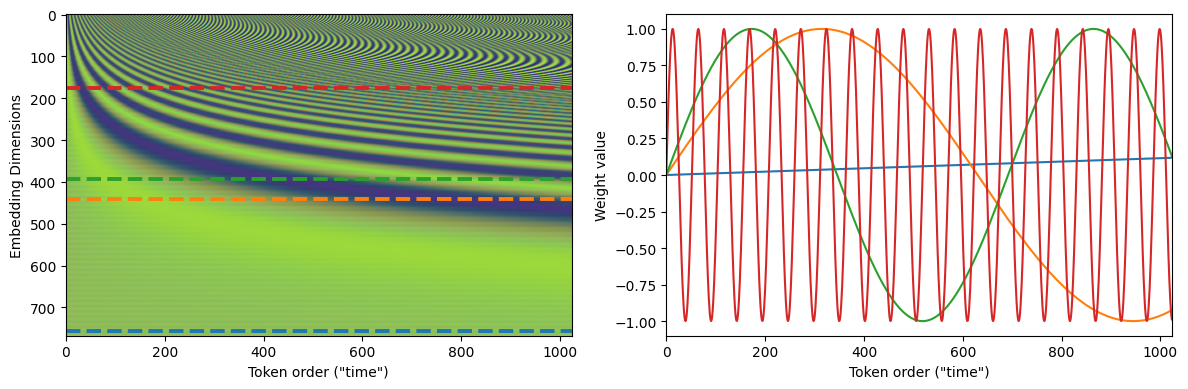

In [ ]:
positions_formula = np.zeros_like(gpt2.wpe.weight.data)
d = positions_formula.shape[1]

# token positions ("time")
th = np.arange(positions_formula.shape[0])

for t in range(0, d, 2):
    denom = 10000 ** (2*(t//2)/d)

    positions_formula[:, t]   = np.sin(th / denom)
    positions_formula[:, t+1] = np.cos(th / denom)

# viz
_, axs = plt.subplots(1,2,figsize=(12,4))

axs[0].imshow(positions_formula.T, vmin=-1, vmax=1, aspect="auto")
axs[0].set(
    ylabel="Embedding Dimensions",
    xlabel='Token order ("time")'
)

poc2show = np.random.randint(0, d, 4)

h = axs[1].plot(positions_formula[:, poc2show])
axs[1].set(
    ylabel="Weight value",
    xlabel='Token order ("time")',
    xlim=[0, len(th)],
    title=""
)

for i, p in enumerate(poc2show):
    axs[0].axhline(
        p,
        linestyle="--",
        color=h[i].get_color(),
        linewidth=2.8
    )

plt.tight_layout()
plt.show()

##### Visualize random embedding dimensions across positions

Each line on right plot represent fluctuations of random dimension over time.

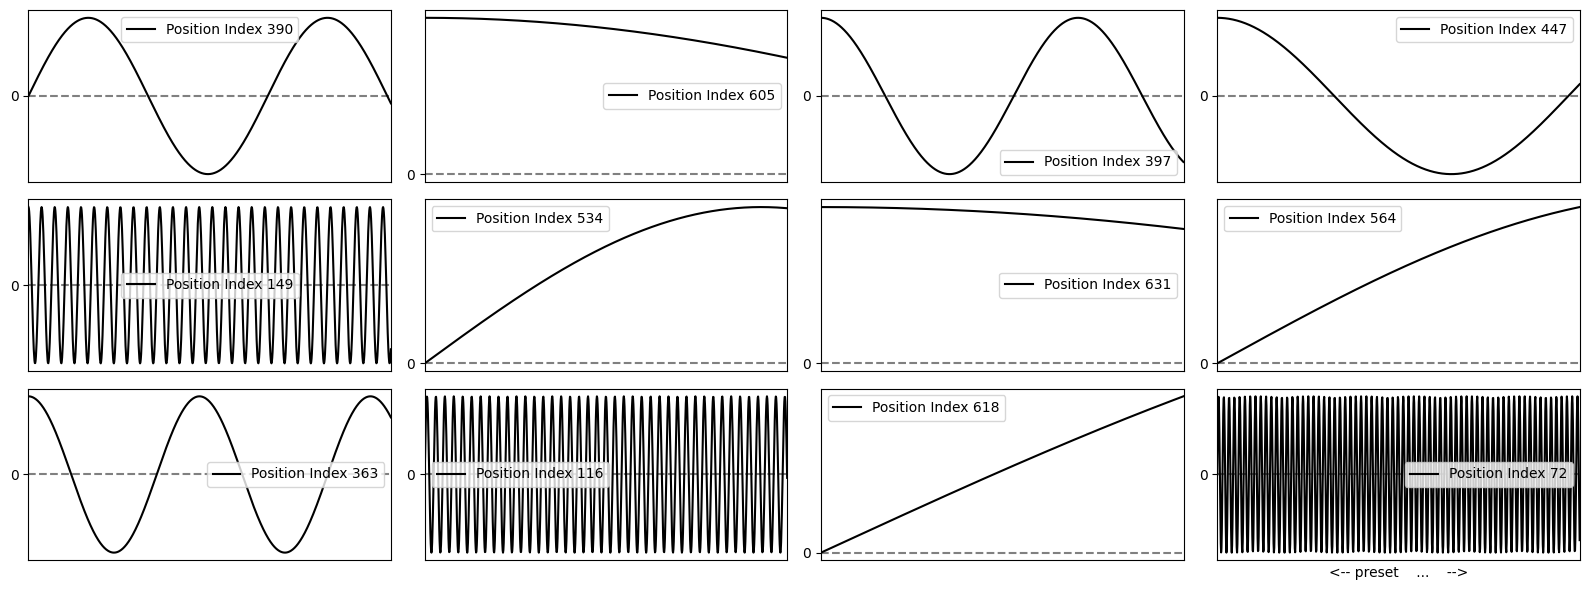

In [ ]:
_, axs = plt.subplots(3,4,figsize=(16,6))

for a in axs.flatten():

    # losowy dimension embeddingu
    rand_idx = np.random.randint(positions_formula.shape[1])

    a.plot(positions_formula[:, rand_idx], 'k',
           label=f'Position Index {rand_idx}')

    a.axhline(0, linestyle='--', color='gray', zorder=-3)

    a.set(
        xticks=[],
        yticks=[0],
        xlim=[0, positions_formula.shape[0]]
    )

    a.legend(fontsize=10)

axs[-1,-1].set(xlabel='<-- preset    ...    -->')

plt.tight_layout()
plt.show()

##### Visualize random position vectors

Now, lets see how each embedding is distributed over dimensions

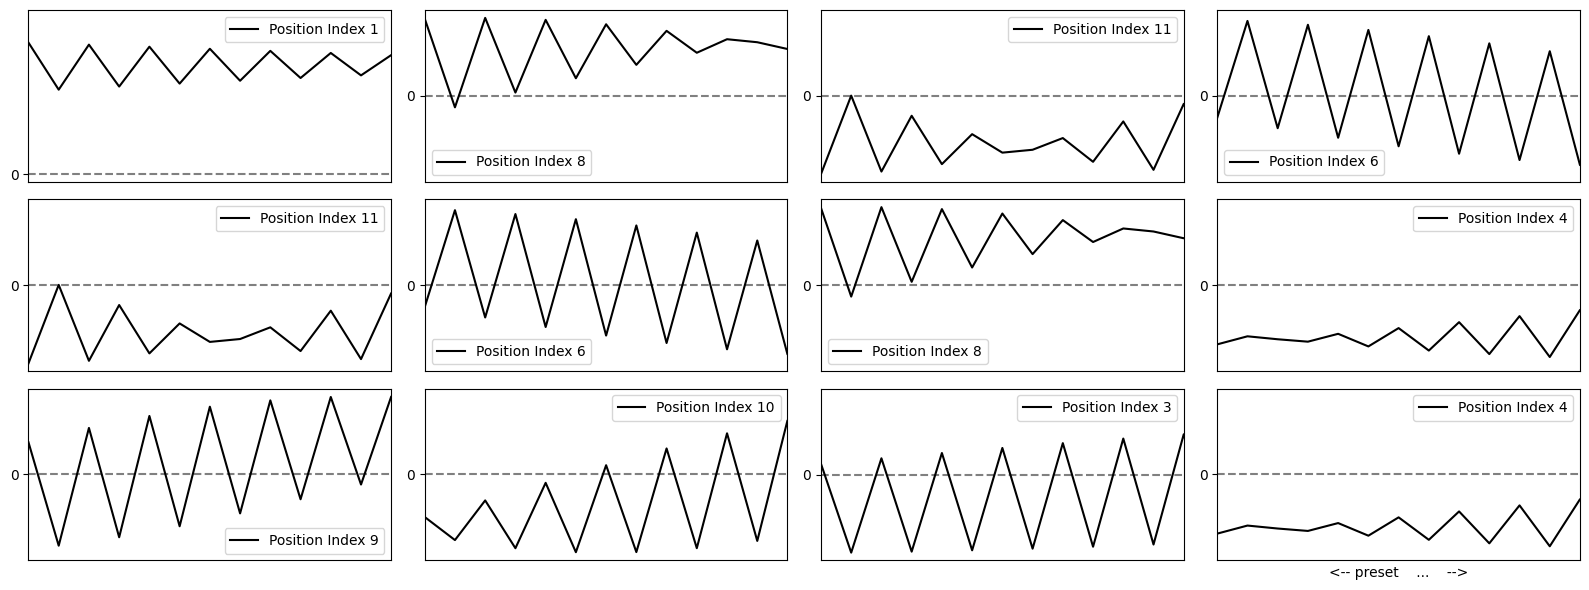

In [ ]:
_, axs = plt.subplots(3,4,figsize = (16,6))

# pick random vectors
for a in axs.flatten():
  # a random position embedding vector
  rand_idx = np.random.randint(positions.shape[0])

  # and plot it
  a.plot(positions_formula[rand_idx,:], 'k', label = f'Position Index {rand_idx}')
  a.axhline(0, linestyle = '--', color = 'gray', zorder = -3)

  a.set(xticks = [], yticks = [0], xlim = [0, positions.shape[0]])
  a.legend(fontsize = 10)

# x-axis label on one plot
a.set(xlabel = '<-- preset    ...    -->')
plt.tight_layout()
plt.show()

### RoPE (Rotary Positional Embeddings)

#### Theory

Instead of adding positional embeddings to token embeddings, RoPE rotates the query and key vectors in the embedding space.

Each pair of dimensions is treated as a 2D vector:

$$ (x_{2i},x_{2i+1}) $$

This vector is rotated by an angle proportional to the token position.

Rotation matrix:

$$ R(\theta)=
\begin{bmatrix}
\cos\theta & -\sin\theta \\
\sin\theta & \cos\theta
\end{bmatrix}
$$

Rotated vector:

$$ x' = R(\theta)x $$

where

$$ \theta = pos \cdot \omega_i $$

and

$$ \omega_i = \frac{1}{10000^{2i/d}} $$

After rotation:

$$ q_i' = R(\theta_i) q_i $$

$$ k_j' = R(\theta_j) k_j $$

The attention score becomes:

$$ q_i' \cdot k_j' = q_i^T R(\theta_i-\theta_j) k_j $$

Therefore attention depends on the relative position:

$$ \theta_i - \theta_j $$

RoPE encodes relative position directly through rotation in the embedding space.

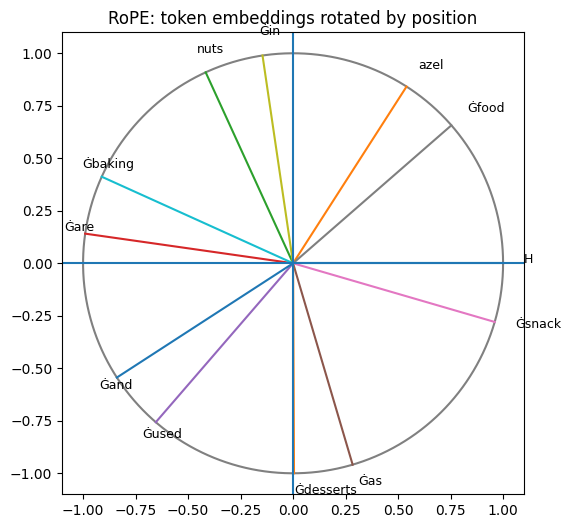

[('H', np.int64(0)), ('azel', np.int64(1)), ('nuts', np.int64(2)), ('Ġare', np.int64(3)), ('Ġused', np.int64(4)), ('Ġas', np.int64(5)), ('Ġsnack', np.int64(6)), ('Ġfood', np.int64(7)), ('Ġin', np.int64(8)), ('Ġbaking', np.int64(9)), ('Ġand', np.int64(10)), ('Ġdesserts', np.int64(11))]


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from transformers import GPT2Tokenizer

# sentence
sentence = "Hazelnuts are used as snack food in baking and desserts"

# tokenizer
tokenizer = GPT2Tokenizer.from_pretrained("gpt2")
ids = tokenizer.encode(sentence)
tokens = tokenizer.convert_ids_to_tokens(ids)

# positions
positions = np.arange(len(tokens))

# base vector (toy query/key vector)
x = np.array([1.0, 0.0])

# RoPE frequency (simplified)
omega = 1.0

plt.figure(figsize=(6,6))

# unit circle
t = np.linspace(0,2*np.pi,200)
plt.plot(np.cos(t), np.sin(t), color="gray")

for pos, tok in zip(positions, tokens):

    theta = pos * omega

    R = np.array([
        [np.cos(theta), -np.sin(theta)],
        [np.sin(theta),  np.cos(theta)]
    ])

    x_rot = R @ x

    plt.plot([0,x_rot[0]],[0,x_rot[1]])
    plt.text(x_rot[0]*1.1,x_rot[1]*1.1,tok,fontsize=9)

plt.axhline(0)
plt.axvline(0)
plt.gca().set_aspect("equal")
plt.title("RoPE: token embeddings rotated by position")
plt.show()

print(list(zip(tokens,positions)))

#### Positional Embeddings Breakdown

##### Generate

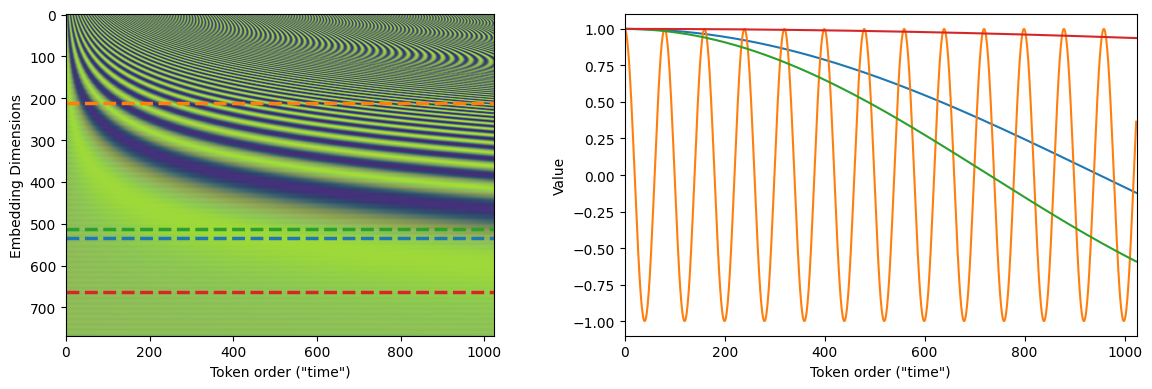

In [ ]:
def build_rope(seq_len, dim, base=10000):
    assert dim % 2 == 0

    positions = np.arange(seq_len)
    freqs = 1.0 / (base ** (np.arange(0, dim, 2) / dim))

    angles = np.outer(positions, freqs)

    rope = np.zeros((seq_len, dim))
    rope[:, 0::2] = np.cos(angles)
    rope[:, 1::2] = np.sin(angles)

    return rope

# create RoPE table
seq_len = 1024
dim = 768

rope = build_rope(seq_len, dim)


# visualization
_, axs = plt.subplots(1,2,figsize=(12,4))

axs[0].imshow(rope.T, vmin=-1, vmax=1)
axs[0].set(ylabel='Embedding Dimensions', xlabel='Token order ("time")')


dims2show = np.random.randint(0, dim, 4)
h = axs[1].plot(rope[:, dims2show])
axs[1].set(ylabel='Value', xlabel='Token order ("time")', xlim=[0, seq_len])

for i,p in enumerate(dims2show):
    axs[0].axhline(p, linestyle='--', color=h[i].get_color(), linewidth=2.5)

plt.tight_layout()
plt.show()

##### Visualize random embedding dimensions across positions

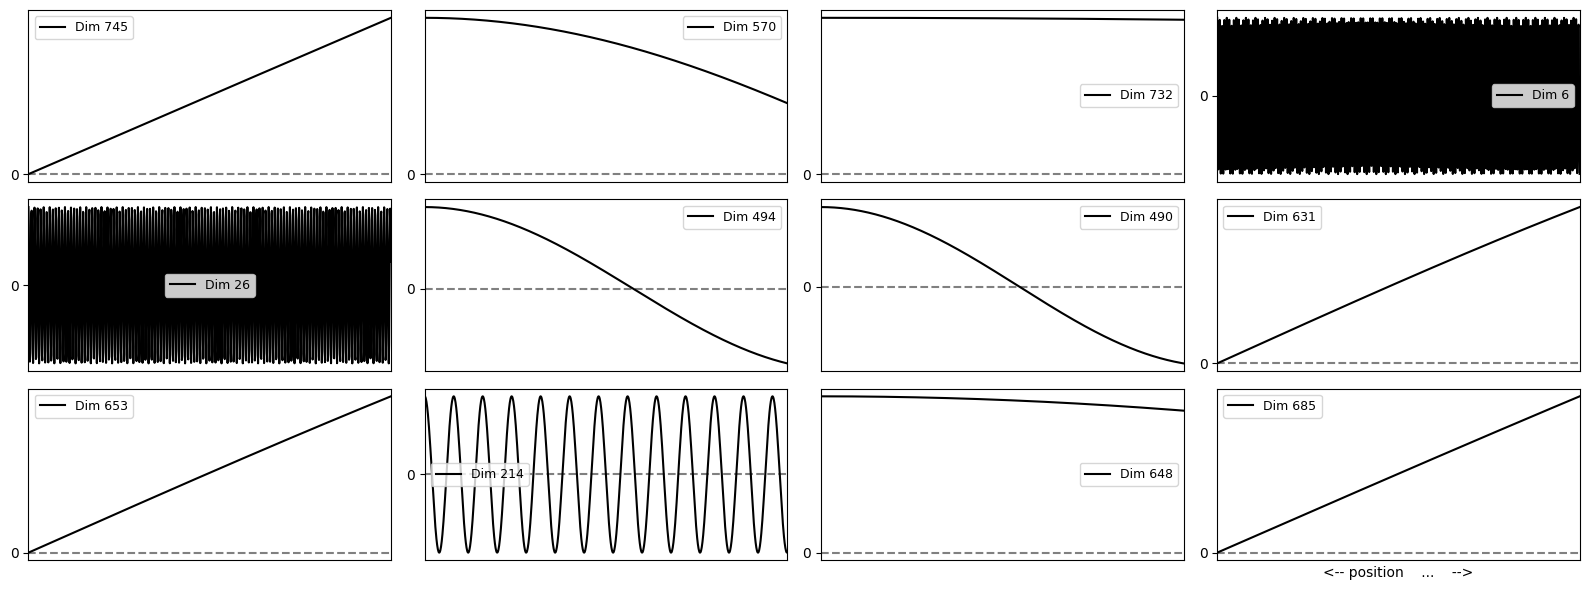

In [ ]:
# random dimension views
_, axs = plt.subplots(3,4,figsize=(16,6))

for a in axs.flatten():
    rand_idx = np.random.randint(dim)
    a.plot(rope[:, rand_idx], 'k', label=f'Dim {rand_idx}')
    a.axhline(0, linestyle='--', color='gray', zorder=-3)

    a.set(xticks=[], yticks=[0], xlim=[0, seq_len])
    a.legend(fontsize=9)

a.set(xlabel='<-- position    ...    -->')
plt.tight_layout()
plt.show()

##### Visualize random position vectors

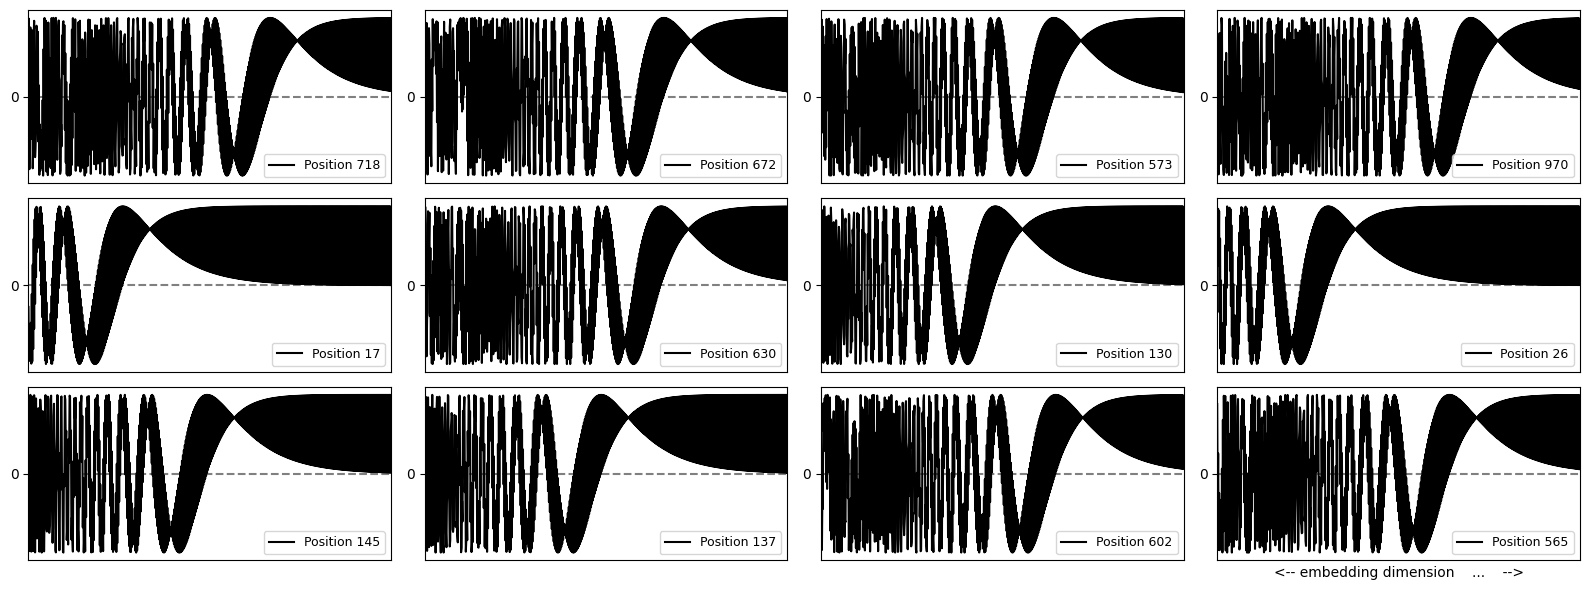

In [ ]:
# random position vectors
_, axs = plt.subplots(3,4,figsize=(16,6))

for a in axs.flatten():
    rand_idx = np.random.randint(seq_len)
    a.plot(rope[rand_idx,:], 'k', label=f'Position {rand_idx}')
    a.axhline(0, linestyle='--', color='gray', zorder=-3)

    a.set(xticks=[], yticks=[0], xlim=[0, dim])
    a.legend(fontsize=9)

a.set(xlabel='<-- embedding dimension    ...    -->')
plt.tight_layout()
plt.show()

# Sources

- Vaswani, A. et al. *Attention Is All You Need*, 2017  
- Mike X Cohen, Deep Understanding of Transformers

{'model': 'nuwan-exp-1', 'params': 31086, 'sensitivity': 0.00663477648049593, 'temporal_usage': 0.22998207807540894, 'diversity': 0.04814847186207771}
{'model': 'mb-dev', 'params': 578308, 'sensitivity': 0.011319693177938461, 'temporal_usage': 0.6849626302719116, 'diversity': 0.07530435174703598}
{'model': 'sn-dev', 'params': 594692, 'sensitivity': 0.012447834946215153, 'temporal_usage': 0.5972904562950134, 'diversity': 0.07824507355690002}
{'model': 'ak-dev', 'params': 2716108, 'sensitivity': 0.2084641009569168, 'temporal_usage': 1.0040507316589355, 'diversity': 0.16393382847309113}


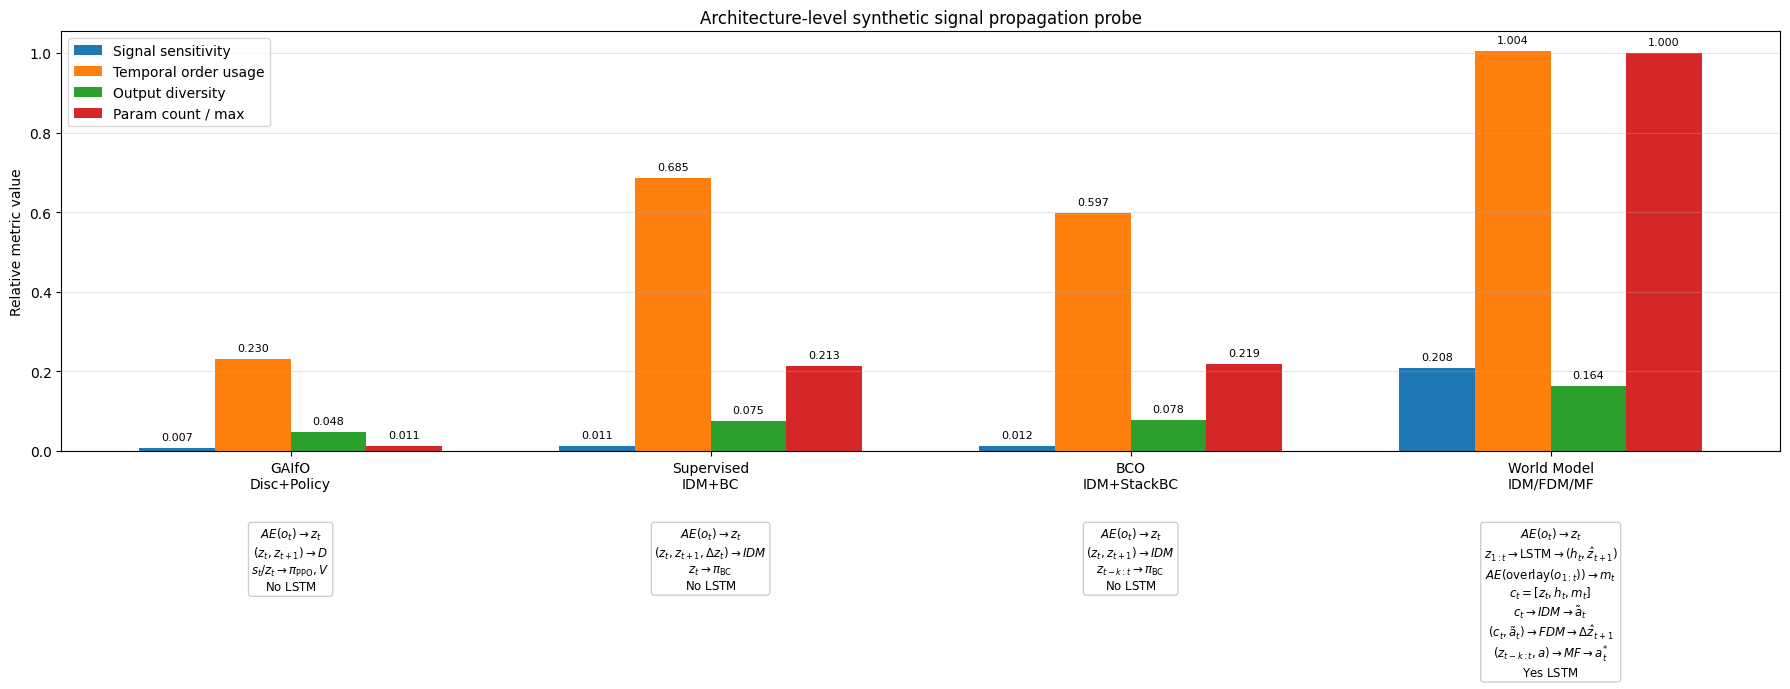

In [7]:
# ============================================================
# Full architecture benchmark + plot
# ============================================================

import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt

torch.manual_seed(42)
np.random.seed(42)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ============================================================
# Shared synthetic signal
# ============================================================

B = 256
Z_DIM = 64
ACTION_DIM = 2
SEQ_LEN = 8
LATENT_A_DIM = 8

def make_signal(batch=B, seq_len=SEQ_LEN, z_dim=Z_DIM, noise=0.03):
    t = torch.linspace(0, 1, seq_len).view(1, seq_len, 1)
    freqs = torch.linspace(1, 4, z_dim).view(1, 1, z_dim)
    phase = torch.rand(batch, 1, z_dim) * 2 * np.pi

    trend = t * torch.randn(batch, 1, z_dim) * 0.4
    wave = torch.sin(2 * np.pi * freqs * t + phase)
    eps = noise * torch.randn(batch, seq_len, z_dim)

    z = wave + trend + eps
    return z.to(DEVICE)

z_seq = make_signal()
z_pert = z_seq + 0.01 * torch.randn_like(z_seq)
z_rev = torch.flip(z_seq, dims=[1])

# ============================================================
# 1. nuwan-exp-1: GAIfO-style discriminator + PPO policy/value
# ============================================================

class NuwanDiscriminator(nn.Module):
    def __init__(self, z_dim=64, hidden_dim=84):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(2 * z_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, 1),
            nn.Sigmoid(),
        )

    def forward(self, z_t, z_tp1):
        return self.net(torch.cat([z_t, z_tp1], dim=-1))


class NuwanPolicyNetwork(nn.Module):
    def __init__(self, state_dim=64, action_dim=2, max_action=1.0, hidden_dim=84):
        super().__init__()
        self.shared = nn.Sequential(
            nn.Linear(state_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
        )
        self.mean_head = nn.Linear(hidden_dim, action_dim)
        self.log_std_head = nn.Linear(hidden_dim, action_dim)
        self.value_head = nn.Linear(hidden_dim, 1)
        self.max_action = max_action

    def forward(self, state):
        x = self.shared(state)
        mean = torch.tanh(self.mean_head(x)) * self.max_action
        log_std = torch.clamp(self.log_std_head(x), -5, 2)
        value = self.value_head(x)
        return mean, log_std, value


# ============================================================
# 2. mb-dev: supervised IDM + latent behavioral cloning
# ============================================================

class MBInverseDynamicsMLP(nn.Module):
    def __init__(self, z_dim=64, action_dim=2, hidden_dim=512):
        super().__init__()
        input_dim = z_dim * 3
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.LayerNorm(hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.LayerNorm(hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.ReLU(),
            nn.Linear(hidden_dim // 2, action_dim),
        )

    def forward(self, z_t, z_tp1):
        dz = z_tp1 - z_t
        return self.net(torch.cat([z_t, z_tp1, dz], dim=1))


class MBLatentPolicy(nn.Module):
    def __init__(self, z_dim=64, action_dim=2, hidden_dim=256):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(z_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, action_dim),
            nn.Tanh(),
        )

    def forward(self, z):
        return self.net(z)


# ============================================================
# 3. sn-dev: BCO IDM + stacked-latent behavioral cloning
# ============================================================

class SNBCOInverseDynamics(nn.Module):
    def __init__(self, z_dim=64, action_dim=2, hidden_dim=512):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(2 * z_dim, hidden_dim),
            nn.LayerNorm(hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.LayerNorm(hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.ReLU(),
            nn.Linear(hidden_dim // 2, action_dim),
        )

    def forward(self, z_t, z_tp1):
        return self.net(torch.cat([z_t, z_tp1], dim=-1))


class SNStackedBCPolicy(nn.Module):
    def __init__(self, z_dim=64, stack=4, action_dim=2, hidden_dim=256):
        super().__init__()
        self.stack = stack
        self.net = nn.Sequential(
            nn.Linear(z_dim * stack, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, action_dim),
            nn.Tanh(),
        )

    def forward(self, z_seq):
        z_stack = z_seq[:, -self.stack:, :].reshape(z_seq.shape[0], -1)
        return self.net(z_stack)


# ============================================================
# 4. ak-dev: World Model + Machine Forward
# ============================================================

class AKLatentLSTM(nn.Module):
    def __init__(self, z_dim=64, hidden_dim=256, num_layers=2, dropout=0.1):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size=z_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0,
        )
        self.head = nn.Sequential(
            nn.LayerNorm(hidden_dim),
            nn.Linear(hidden_dim, hidden_dim),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, z_dim),
        )

    def forward(self, z_seq):
        h_seq, (h_n, _) = self.lstm(z_seq)
        z_pred = self.head(h_n[-1])
        return h_seq, z_pred


class AKIDMModel(nn.Module):
    def __init__(self, c_dim=384, latent_a_dim=8):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(c_dim, 512),
            nn.LayerNorm(512),
            nn.GELU(),
            nn.Linear(512, 512),
            nn.LayerNorm(512),
            nn.GELU(),
            nn.Linear(512, 256),
            nn.LayerNorm(256),
            nn.GELU(),
            nn.Linear(256, 128),
            nn.LayerNorm(128),
            nn.GELU(),
            nn.Linear(128, latent_a_dim),
            nn.Tanh(),
        )

    def forward(self, c_t):
        return self.net(c_t)


class AKFDMModel(nn.Module):
    def __init__(self, c_dim=384, z_dim=64, latent_a_dim=8):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(c_dim + latent_a_dim, 256),
            nn.LayerNorm(256),
            nn.GELU(),
            nn.Linear(256, 512),
            nn.LayerNorm(512),
            nn.GELU(),
            nn.Linear(512, 512),
            nn.LayerNorm(512),
            nn.GELU(),
            nn.Linear(512, 256),
            nn.LayerNorm(256),
            nn.GELU(),
            nn.Linear(256, 128),
            nn.LayerNorm(128),
            nn.GELU(),
            nn.Linear(128, z_dim),
        )

    def forward(self, c_t, latent_a):
        return self.net(torch.cat([c_t, latent_a], dim=-1))


class AKMachineForwardModel(nn.Module):
    def __init__(self, z_dim=64, real_a_dim=2, hidden_dim=256):
        super().__init__()
        self.history_encoder = nn.LSTM(
            input_size=z_dim,
            hidden_size=hidden_dim,
            num_layers=1,
            batch_first=True,
        )
        self.head = nn.Sequential(
            nn.LayerNorm(hidden_dim + real_a_dim),
            nn.Linear(hidden_dim + real_a_dim, hidden_dim),
            nn.GELU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.GELU(),
            nn.Linear(hidden_dim, z_dim),
        )

    def forward(self, z_hist, a_real):
        _, (h_n, _) = self.history_encoder(z_hist)
        h_t = h_n[-1]
        return self.head(torch.cat([h_t, a_real], dim=-1))


class AKWorldModelPipeline(nn.Module):
    def __init__(self, z_dim=64, latent_a_dim=8, action_dim=2):
        super().__init__()
        self.lstm = AKLatentLSTM(z_dim=z_dim)
        self.idm = AKIDMModel(c_dim=384, latent_a_dim=latent_a_dim)
        self.fdm = AKFDMModel(c_dim=384, z_dim=z_dim, latent_a_dim=latent_a_dim)
        self.machine = AKMachineForwardModel(z_dim=z_dim, real_a_dim=action_dim)

    def forward(self, z_seq):
        h_seq, z_lstm_next = self.lstm(z_seq)
        z_t = z_seq[:, -1]
        h_t = h_seq[:, -1]

        # m_t proxy: real model uses AE(overlay frames) -> m_t
        m_t = z_seq.mean(dim=1)

        c_t = torch.cat([z_t, h_t, m_t], dim=-1)

        latent_a = self.idm(c_t)
        dz_desired = self.fdm(c_t, latent_a)

        a_zero = torch.zeros(z_seq.shape[0], ACTION_DIM, device=z_seq.device)
        dz_machine = self.machine(z_seq[:, -8:], a_zero)

        return dz_desired, latent_a, dz_machine


# ============================================================
# Metrics
# ============================================================

def count_params(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)


def output_flat(y):
    if isinstance(y, tuple):
        y = torch.cat(
            [v.reshape(v.shape[0], -1) for v in y if torch.is_tensor(v)],
            dim=-1,
        )
    return y.reshape(y.shape[0], -1)


@torch.no_grad()
def sensitivity(model, fwd, x, x_pert):
    y = output_flat(fwd(model, x))
    yp = output_flat(fwd(model, x_pert))
    return (
        (yp - y).norm(dim=1)
        / ((x_pert - x).reshape(x.shape[0], -1).norm(dim=1) + 1e-8)
    ).mean().item()


@torch.no_grad()
def temporal_usage(model, fwd, x, x_rev):
    y = output_flat(fwd(model, x))
    yr = output_flat(fwd(model, x_rev))
    return ((yr - y).norm(dim=1) / (y.norm(dim=1) + 1e-8)).mean().item()


@torch.no_grad()
def output_diversity(model, fwd, x):
    y = output_flat(fwd(model, x))
    return y.std(dim=0).mean().item()


# ============================================================
# Build models and forward wrappers
# ============================================================

models = {}

nuwan_disc = NuwanDiscriminator().to(DEVICE)
nuwan_policy = NuwanPolicyNetwork().to(DEVICE)
models["nuwan-exp-1"] = (
    nn.ModuleList([nuwan_disc, nuwan_policy]),
    lambda m, x: (
        m[0](x[:, -2], x[:, -1]),
        m[1](x[:, -1])[0],
        m[1](x[:, -1])[2],
    ),
)

mb_idm = MBInverseDynamicsMLP().to(DEVICE)
mb_policy = MBLatentPolicy().to(DEVICE)
models["mb-dev"] = (
    nn.ModuleList([mb_idm, mb_policy]),
    lambda m, x: (
        m[0](x[:, -2], x[:, -1]),
        m[1](x[:, -1]),
    ),
)

sn_idm = SNBCOInverseDynamics().to(DEVICE)
sn_policy = SNStackedBCPolicy(stack=4).to(DEVICE)
models["sn-dev"] = (
    nn.ModuleList([sn_idm, sn_policy]),
    lambda m, x: (
        m[0](x[:, -2], x[:, -1]),
        m[1](x),
    ),
)

ak_world = AKWorldModelPipeline().to(DEVICE)
models["ak-dev"] = (
    ak_world,
    lambda m, x: m(x),
)

# ============================================================
# Run benchmark
# ============================================================

rows = []

for name, (model, fwd) in models.items():
    model.eval()
    rows.append({
        "model": name,
        "params": count_params(model),
        "sensitivity": sensitivity(model, fwd, z_seq, z_pert),
        "temporal_usage": temporal_usage(model, fwd, z_seq, z_rev),
        "diversity": output_diversity(model, fwd, z_seq),
    })

for r in rows:
    print(r)

# ============================================================
# Plot: architecture-level synthetic signal propagation probe
# ============================================================

names = [r["model"] for r in rows]
params = np.array([r["params"] for r in rows], dtype=float)
sens = np.array([r["sensitivity"] for r in rows])
temp = np.array([r["temporal_usage"] for r in rows])
div = np.array([r["diversity"] for r in rows])

params_norm = params / params.max()

display_names = {
    "nuwan-exp-1": "GAIfO\nDisc+Policy",
    "mb-dev": "Supervised\nIDM+BC",
    "sn-dev": "BCO\nIDM+StackBC",
    "ak-dev": "World Model\nIDM/FDM/MF",
}

xtick_labels = [display_names.get(n, n) for n in names]

equation_blocks = {
    "nuwan-exp-1":
        r"$AE(o_t)\to z_t$" "\n"
        r"$(z_t,z_{t+1})\to D$" "\n"
        r"$s_t/z_t\to \pi_{\mathrm{PPO}},V$" "\n"
        r"$\mathrm{No\ LSTM}$",

    "mb-dev":
        r"$AE(o_t)\to z_t$" "\n"
        r"$(z_t,z_{t+1},\Delta z_t)\to IDM$" "\n"
        r"$z_t\to \pi_{\mathrm{BC}}$" "\n"
        r"$\mathrm{No\ LSTM}$",

    "sn-dev":
        r"$AE(o_t)\to z_t$" "\n"
        r"$(z_t,z_{t+1})\to IDM$" "\n"
        r"$z_{t-k:t}\to \pi_{\mathrm{BC}}$" "\n"
        r"$\mathrm{No\ LSTM}$",

    "ak-dev":
        r"$AE(o_t)\to z_t$" "\n"
        r"$z_{1:t}\to \mathrm{LSTM}\to(h_t,\hat z_{t+1})$" "\n"
        r"$AE(\mathrm{overlay}(o_{1:t}))\to m_t$" "\n"
        r"$c_t=[z_t,h_t,m_t]$" "\n"
        r"$c_t\to IDM\to \tilde a_t$" "\n"
        r"$(c_t,\tilde a_t)\to FDM\to \Delta \hat z_{t+1}$" "\n"
        r"$(z_{t-k:t},a)\to MF\to a_t^{*}$" "\n"
        r"$\mathrm{Yes\ LSTM}$",
}

eq_labels = [equation_blocks.get(n, "") for n in names]

x = np.arange(len(names))
w = 0.18

fig, ax = plt.subplots(figsize=(18, 7))

bars1 = ax.bar(x - 1.5*w, sens, width=w, label="Signal sensitivity")
bars2 = ax.bar(x - 0.5*w, temp, width=w, label="Temporal order usage")
bars3 = ax.bar(x + 0.5*w, div, width=w, label="Output diversity")
bars4 = ax.bar(x + 1.5*w, params_norm, width=w, label="Param count / max")

ax.set_xticks(x)
ax.set_xticklabels(xtick_labels, fontsize=10)
ax.set_ylabel("Relative metric value")
ax.set_title("Architecture-level synthetic signal propagation probe")
ax.grid(True, axis="y", alpha=0.3)
ax.legend(loc="upper left")

def add_bar_labels(bar_container, fmt="{:.3f}", fontsize=8):
    for bar in bar_container:
        h = bar.get_height()
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            h + 0.015,
            fmt.format(h),
            ha="center",
            va="bottom",
            fontsize=fontsize,
            rotation=0,
        )

add_bar_labels(bars1, fmt="{:.3f}")
add_bar_labels(bars2, fmt="{:.3f}")
add_bar_labels(bars3, fmt="{:.3f}")
add_bar_labels(bars4, fmt="{:.3f}")

plt.subplots_adjust(bottom=0.28)

for i, txt in enumerate(eq_labels):
    ax.text(
        x[i],
        -0.18,
        txt,
        ha="center",
        va="top",
        fontsize=8.5,
        transform=ax.get_xaxis_transform(),
        bbox=dict(
            boxstyle="round,pad=0.25",
            facecolor="white",
            edgecolor="0.8",
            alpha=0.95,
        ),
    )

plt.savefig(
    "architecture_signal_probe_latex_with_bar_values.png",
    dpi=200,
    bbox_inches="tight",
)

plt.tight_layout()
plt.show()